# gebhart2019 — Gebhart et al. (2019) — Characterizing Activation Space

Activation-weighted graph: edge weight = |W_ij * h_i| where h_i is the pre-synaptic activation.  Long H0 bars correspond to prominent signal pathways.


## What the paper does

Where Neural Persistence uses weights alone, this paper makes the graph **input-dependent**: each edge is weighted by `|W_ij · h_i|`, the product of the weight and the *pre-synaptic activation* `h_i` for a given input. Persistent homology of that activation-weighted graph yields `H0` generators whose long-lifetime bars correspond to the network's most prominent, *distinct* **signal pathways** for that input.

**Methodology:** coupled (weight, pre-activation) per layer → `|w·h|` activation graph → `H0` PH → long bars = salient pathways.

**The pathways are real H0 representatives.** For a graph, `H0` persistence *is* single-linkage clustering: the merge tree is the **maximum spanning forest**, and the longest-lifetime `H0` bars are its weakest tree edges.  Cutting the top few splits the network into its most persistent clusters — the distinct pathways.  The plot below (`mode='h0'`) colours each pathway and dashes the `H0` *death* edges that separate them — unlike a top-|w| magnitude heuristic, which is *not* topological.

**Expected result:** the `H0` barcode isolates a handful of long bars (task-relevant pathways) above a band of short, noise-level bars; those pathways are the coloured clusters on the network graph.


## Dataset & model in the paper

- **arXiv:** [https://arxiv.org/abs/1901.09496](https://arxiv.org/abs/1901.09496)
- **Venue:** ICMLA 2019
- **Datasets used:** MNIST.
- **Models used:** Small MLPs trained for digit classification.
- **Headline result to aim for:** H0 persistence intervals of activation graphs identify task-relevant substructures.
- **Reference code:** no public repo found in web search — check paper supplementary materials.

To reproduce paper numbers, replace the synthetic-data cell below with the real model snapshot / activations / trajectory.  Everything else in the notebook stays the same.


**This notebook now runs on real data.**  A tiny model is trained briefly on the local dataset cache under `data/`.  Headline numbers won't match the paper (that needs full training on GPU); the *qualitative* behaviour the paper reports should still appear.


In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))  # make `paper_reproduce` importable
import numpy as np
import matplotlib.pyplot as plt
import torch
from tanc import TDAPipeline
from paper_reproduce._torch_setup import (
    load_mnist, load_fashion_mnist, load_cifar10, load_cifar100,
    SmallMLP, SmallCNN, CNN_FCN, CNN_FCN2, VGGLike, train_briefly, extract_snapshot, pick_device,
)
np.random.seed(0); torch.manual_seed(0)
DEVICE = pick_device()                      # 'cuda' → 'mps' (Apple GPU) → 'cpu'


## 1. Load dataset + train a small model briefly


In [2]:
# Tiny MLP on MNIST + an extracted snapshot on a small input batch.
X_tr, y_tr = load_mnist('train', n_samples=2000)
X_te, y_te = load_mnist('test',  n_samples=400)

model = SmallMLP(input_dim=784, hidden_dims=[64, 32], output_dim=10)
view  = train_briefly(model, X_tr, y_tr, X_te, y_te, epochs=2)
snap  = extract_snapshot(model, X_te[:64],
                        aspects=['weights', 'activations'])
snap.inputs = X_te[:64]   # so coupled_weight_activations can fill the first layer
print(f'snapshot ready: {len(snap.weights)} weight layers')


TrainingExtractor (framework=pytorch)
  aspects          : ['weights', 'activations']
  layers (3): ['fc1', 'fc2', 'fc3']
  snapshots        : every 1 epoch(s)
  batch_size       : 128
  device           : mps
  train_loader     : DataLoader
  criterion        : CrossEntropyLoss
  optimizer        : Adam
  val_loader       : DataLoader
  scheduler        : (not set)
  loss_eval_data   : (not set)


Epoch 1/2  loss=2.0362
  [snapshot] epoch=1  loss=2.0362  acc=0.6900
Epoch 2/2  loss=1.1423
  [snapshot] epoch=2  loss=1.1423  acc=0.7750
snapshot ready: 3 weight layers


## 2. Reproduce via `TDAPipeline.from_paper` — model-first

We hand the trained model object straight to the pipeline: `from_paper` already knows what this paper needs, and the pipeline's model-adapter extracts it for us — no manual feature pulling required.


In [3]:
pipe = TDAPipeline.from_paper("gebhart2019")
pipe.explain()


TDAPipeline — Gebhart et al. (2019)
  Stage 1: builder = weight_graph
             edge_weight = 'weighted_activation'
             graph_scope = 'multipartite'
             induced_paths = False
             node_feature_fn = 'laplacian_eigenvectors'
  Stage 2: tool    = ph
             max_dim = 0
             backend = 'ripser'
  Default plot   : .plot('diagram')


"TDAPipeline — Gebhart et al. (2019)\n  Stage 1: builder = weight_graph\n             edge_weight = 'weighted_activation'\n             graph_scope = 'multipartite'\n             induced_paths = False\n             node_feature_fn = 'laplacian_eigenvectors'\n  Stage 2: tool    = ph\n             max_dim = 0\n             backend = 'ripser'\n  Default plot   : .plot('diagram')"

TopoResult(tool='ph')
  paper       : Gebhart et al. (2019)
  data        : ph_result (H0: 889 bars)
  statistics  : H0_total_persistence, H0_persistence_norm, H0_betti_curve, H0_persistence_entropy
  plots       :
    .plot('diagram') — Birth-vs-death scatter of persistence pairs.
    .plot('barcode') — Horizontal bars from birth to death, sorted by birth.
    .plot('betti_curve') — Step function of Betti_d across the filtration range.
  config keys : max_dim, coeff, backend, input_type, matrix_type, epsilon, k, filtration_schedule (+1 more)


"TopoResult(tool='ph')\n  paper       : Gebhart et al. (2019)\n  data        : ph_result (H0: 889 bars)\n  statistics  : H0_total_persistence, H0_persistence_norm, H0_betti_curve, H0_persistence_entropy\n  plots       :\n    .plot('diagram') — Birth-vs-death scatter of persistence pairs.\n    .plot('barcode') — Horizontal bars from birth to death, sorted by birth.\n    .plot('betti_curve') — Step function of Betti_d across the filtration range.\n  config keys : max_dim, coeff, backend, input_type, matrix_type, epsilon, k, filtration_schedule (+1 more)"

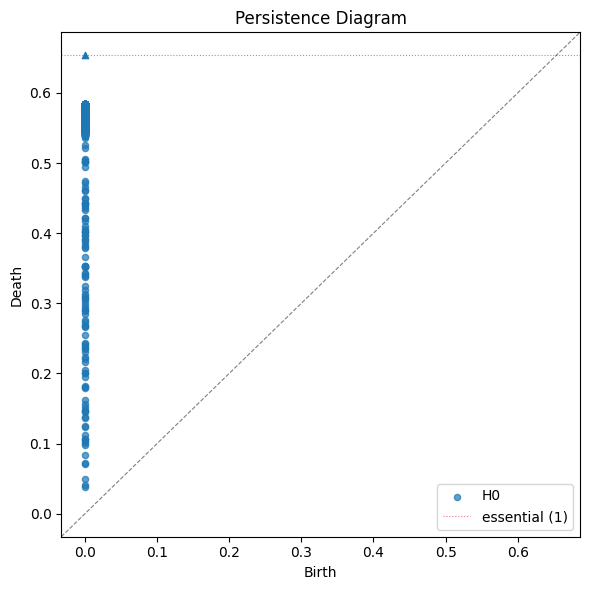

In [4]:
result, fig = pipe.reproduce(snap)
result.describe()


## 3. Paper-specific follow-up plot


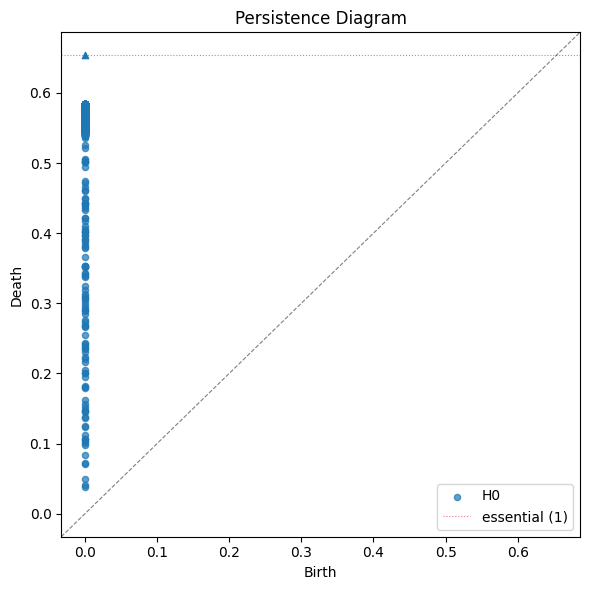

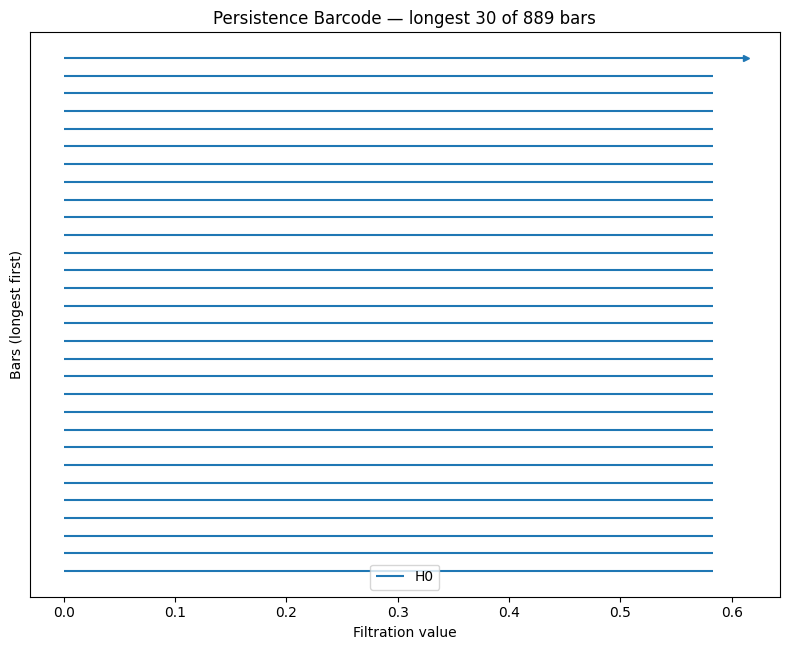

In [5]:
# H0 of the |w.h| activation graph.  The diagram + the LONGEST bars:
fig = result.plot("diagram", dims=[0])
fig = result.plot("barcode", dims=[0], max_bars=30)   # capped, longest first


## 4. H0 signal pathways — coloured by persistent cluster (faithful)

We build the **activation-weighted** edges `|w·h|` (the graph the H0 above is computed on) and highlight the **maximum-spanning-tree (merge-tree) edges** — the genuine H0 representatives — coloured by which of the top `n_pathways` persistent clusters they belong to.  Dashed black edges are the H0 *deaths* that separate the pathways.  The 784-pixel input layer is dropped for readability, so pathways are shown through the hidden neurons (`L0`=hidden-1, `L1`=hidden-2, `L2`=outputs).


activation-weighted layers: [(784, 64), (64, 32), (32, 10)]


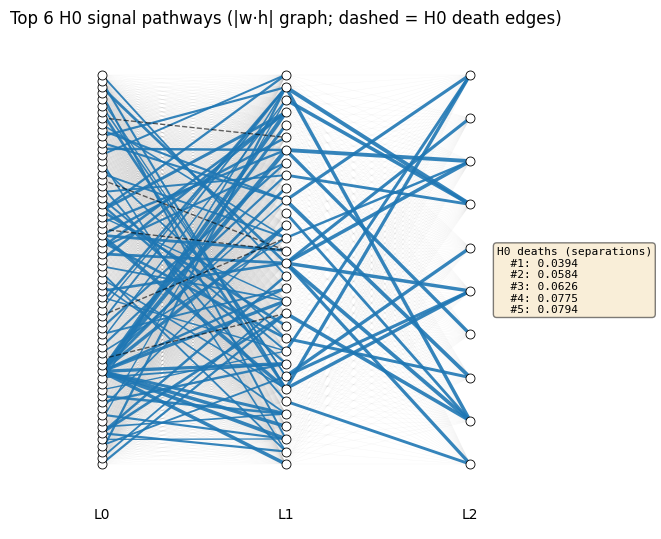

In [6]:
from tanc.visualisation import plot_pathways_on_network

# |w . h| activation-weighted edges, per layer (mean over the batch).
coupled = snap.coupled_weight_activations()      # [(W, pre_act), ...]
phi = [np.abs(W * pre.mean(axis=0)[:, None]) for W, pre in coupled]
print('activation-weighted layers:', [p.shape for p in phi])

# Faithful H0 pathways over the hidden neurons (drop the pixel layer).
fig = plot_pathways_on_network(phi[1:], mode='h0', n_pathways=6)


## Notes & gaps

* Implements the method as described,: `|w·h|` activation-graph H0 PH on real MNIST activations, with the pathways drawn as the **actual H0 representative clusters** (maximum spanning forest), not a magnitude heuristic.
* `plot_pathways_on_network(..., mode='magnitude')` keeps the old top-|w| proxy; `mode='h0'` is the topological version.
* `result.plot('barcode', max_bars=N)` caps a dense H0 barcode to the N longest bars (the essential bar is marked `>`).


## Deviations from the paper

Everything this notebook does differently from the source, and why. An empty
table below means the construction follows the paper as written — that is a
claim, not an omission. Scale always differs; see the last row.

| aspect | the paper | this notebook | why it matters |
|---|---|---|---|
| activation aggregation | per-input activation graphs | activations averaged over the batch before forming edge weights | one representative graph per layer instead of one per sample |
| scale | the paper's full experimental setup | a smaller model, fewer samples, fewer epochs | to keep the notebook runnable in minutes; expect weaker effects than published |
